# Regressão Logística nos dados covtype de LIBSVM

Iremos treinar os dados para classificação binária usando os dados `covtype` da biblioteca [LIBSVM](https://www.csie.ntu.edu.tw/~cjlin/libsvm/). Veja também [Kaggle-LIBSVM](https://www.kaggle.com/code/tanmayunhale/libsvm-liblinear).

Queremos minimizar

$$
\min_{w\in {\mathbb R}^{d\times1}} f(w)=-\frac{1}{n}\sum_{i=1}^n \left(y_i \log (s(x_i^\top w)) + (1 - y_i) \log (1 - s(x_i^\top w))\right) + \frac{\gamma}{2}\|w\|^2,
$$

onde $x_i\in {\mathbb R}^{d\times1}$, $y_i\in \{0, 1\}$, $s(z)=\frac{1}{1+\exp(-z)}$ é a função sigmóide. O gradiente é dado por

$$
\nabla f(w) = \frac{1}{n}\sum_{i=1}^n x_i(s(x_i^\top w)-y_i) + \gamma w.
$$

Esta é uma função suave com constante de Lipschitz $L=L_0+\gamma$ onde

$$
L_0 = \frac{1}{4}\lambda_{\max}\left(\frac{X^\top X}{n}\right),
$$ 

onde $X\in\mathbb{R}^{n\times d}$ é a matriz de dados cuja $i$-ézima linha é o vetor $x_i^\top$ e $\lambda_{\max}(\cdot)$ denota o maior autovalor.

In [6]:
# Importação de módulos necesserários:

import matplotlib
import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import numpy.linalg as la
from sklearn.datasets import load_svmlight_file
from sklearn.utils.extmath import safe_sparse_dot

In [7]:
# Lendo os dados do arquivo covtype e guardando na matriz de dados X e vetor de labels y:

data = load_svmlight_file('covtype.bz2')
X, y = data[0].toarray(), data[1]
if (np.unique(y) == [1, 2]).all():
    # Devemos garantir que os labels estão em {0, 1}
    y -= 1    
    
n, d = X.shape # tamanho da amostra, número de features    

# Exercício 1: Funções auxiliares

1. Construa uma função `smoothness(X)` que toma a matriz de dados `X` e retorna a constante $L_0$.
2. Construa uma função `f(w, X, y, l2)` que toma o iterado `w`, os dados `X, y` e a penalização $\gamma$ (=`l2`) e retorna o valor funcional $f(w)$.
3. Construa uma função `df(w, X, y, l2)` toma o iterado `w`, os dados `X, y` e a penalização $\gamma$ (=`l2`) e retorna o gradiente $\nabla f(w)$.

In [8]:
#Escreva código aqui

# 1. Constante L_0

def smoothness(X):
    n = X.shape[0]
    M = (X.T @ X) / n
    autovalores = la.eigvalsh(M)
    maior_autovalor = np.max(autovalores)
    L0 = (1/4) * maior_autovalor

    return L0


# 2. Valor funcional f(w)

def f(w, X, y, l2):
    n = X.shape[0]
    Xw = X @ w
    sigm_Xw = 1 / (1 + np.exp(-Xw))
    
    erro = np.sum(y * np.log(sigm_Xw) + (1 - y) * np.log(1 - sigm_Xw))
    peso = (l2 / 2) * (la.norm(w)**2)

    valor_func = -(1 / n) * erro + peso

    return valor_func


# 3. Gradiente de f(w)

def df(w, X, y, l2):
    n = X.shape[0]
    Xw = X @ w
    sigm_Xw = 1 / (1 + np.exp(-Xw))
    erro_vetor = sigm_Xw - y

    d_erro = (1 / n) * (X.T @ erro_vetor)
    d_peso = l2 * w

    gradiente = d_erro + d_peso

    return gradiente

# Inicialização

Fixaremos:

In [9]:
L0 = smoothness(X)
l2 = L0 / n
L = L0 + l2
w0 = np.zeros(d)        # ponto inicial
it_max = 10000          # número de iterações

#Função de desempenho é a norma de Frobenius:
J = lambda w: la.norm(w)

#Função que retorna gradiente (para X,y,l2) já declarados.
def Df(w):
    return df(w, X, y, l2)

l2

np.float64(8.676367672880712)

# Exercício 2: Método do gradiente

Construa uma função `gd(df, w0, la=1, numb_iter=100)` que toma como entrada as funções `J()` `df()`, o ponto inicial `w0`, o passo `la` e o número de iterações `numb_iter` e implementa o método gradiente iniciando de `w0`. Esta função deve retornar a sequência de valores da função $\Vert\nabla f(w)\Vert_2$ em cada um dos iterados $w$. A função também deve retornar o último iterado. 

Implemente a função com passo `la=1./L` 

In [10]:
#Escreva código aqui

def gd(J, df, w0, la=1, numb_iter=100):
    valores_funcao = []
    w = w0.copy()

    for _ in range(numb_iter):
        gradiente = df(w)
        grad_norm = J(gradiente)
        valores_funcao.append(grad_norm)

        w = w - la * gradiente

    return valores_funcao, w

In [11]:
# gradient descent
f1 = gd(J, Df, w0, la=1./L, numb_iter=it_max)

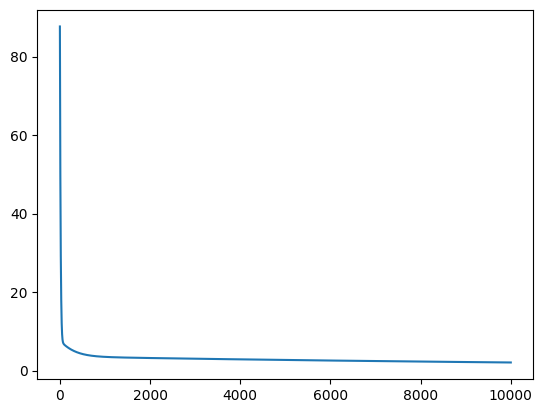

In [12]:
plt.plot(f1[0])

# Exercício 3: Método do gradiente acelerado

Construa uma função `accel_gd(J, df, w0, la=1, numb_iter=100)` que toma como entrada as funções `J()`, `df()`, o ponto inicial `w0`, o passo `la` e o número de iterações `numb_iter` e implementa o método gradiente com aceleração de Nesterov iniciando de `w0` e $t_0=1$:
\begin{align*}
w_{k+1}&:= y_k - la\nabla f(y_k),\\
t_{k+1} &:= \frac{1+\sqrt{1+4t_k^2}}{2},\\
y_{k+1} &:= w_{k+1} + \frac{t_{k}-1}{t_{k+1}}(w_{k+1}-w_{k}).
\end{align*}
Esta função deve retornar a sequência de valores da função `J(df(y))` em cada um dos iterados `y`, isto é, a sequência das normas dos gradientes de $y_k$ ao longo da trajetória do método. A função também deve retornar o último iterado. 

Implemente a função com passo `la=1./L`.

In [13]:
#Escreva código aqui

def accel_gd(J, df, w0, la=1, numb_iter=100):
    norm_gd_y = []
    w_k = w0.copy()
    y_k = w0.copy()
    t_k = 1

    for _ in range(numb_iter):
        grad = df(y_k)
        norm_gd_y.append(J(grad))

        w_k1 = y_k - la * grad
        t_k1 = (1 + np.sqrt(1 + 4 * t_k**2)) / 2
        y_k1 = w_k1 + ((t_k - 1) / t_k1) * (w_k1 - w_k)

        w_k = w_k1
        t_k = t_k1
        y_k = y_k1

    return norm_gd_y, w_k


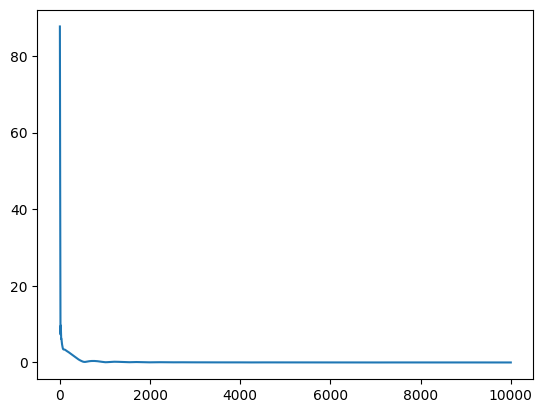

In [14]:
# Nesterov accelerated gradient descent
f2 = accel_gd(J, Df, w0, la=1./L, numb_iter=it_max)
plt.plot(f2[0])

# Exercício 4: Método do gradiente acelerado com $\gamma$

Construa uma função `accel_gd_sc(J, df, w0, la=1, kappa, numb_iter=100)` que toma como entrada as funções `J()`, `df()`, o ponto inicial `w0`, o passo `la` e o número de iterações `numb_iter` e implementa o método gradiente com aceleração de Nesterov iniciando de `y0=w0`:
\begin{align*}
w_{k+1}&:= y_k - la\nabla f(y_k),\\
y_{k+1} &:= w_{k+1} + \frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}(w_{k+1}-w_{k}).
\end{align*}
Àcima, $\kappa:=L/\gamma$. Esta função deve retornar a sequência de valores da função `J(df(y))` em cada um dos iterados `y`, isto é, a sequência das normas dos gradientes de $y_k$ ao longo da trajetória do método. A função também deve retornar o último iterado. 

Implemente a função com passo `la=1./L`.

In [15]:
#Escreva código aqui

def accel_gd_sc(J, df, w0, la=1, kappa=L/l2, numb_iter=100):
    w_k = w0.copy()
    y_k = w0.copy()
    grad_y_norm = []

    for _ in range(numb_iter):
        grad = df(y_k)
        grad_y_norm.append(J(grad))

        w_k1 = y_k - la * grad
        y_k1 = w_k1 + ((np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)) * (w_k1 - w_k)

        w_k = w_k1
        y_k = y_k1

    return grad_y_norm, w_k


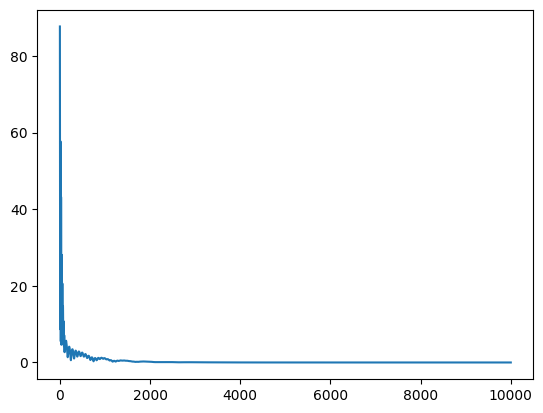

In [16]:
# Nesterov accelerated gradient descent for strongly convex functions
f3 = accel_gd_sc(J, Df, w0, la=1./L, kappa=L/l2, numb_iter=it_max)
plt.plot(f3[0])

# Exercício 5: Adagrad-Norm

Construa uma função `ad_grad_norm(J, Df, w0, b0=0.5, eta=1, numb_iter=100)` que toma como entrada as funções `J()`, `Df`, o ponto inicial `w0`, parametros positivos `b0` e `eta` e o número de iterações `numb_iter` e implementa o método Adagrad-Norm iniciando de `w0`:
\begin{align*}
w_{k+1}&:= w_k - \frac{\eta}{\sqrt{b_0^2 + \sum_{j=1}^k\Vert\nabla f(w_j)\Vert_2^2}} \nabla f(w_k).
\end{align*}
Esta função deve retornar a sequência de valores da função `J(Df(w))` em cada um dos iterados `w`, isto é, a sequência das normas dos gradientes de $X_k$ ao longo da trajetória do método. A função também deve retornar o último iterado. 

Implemente a função com `b0=0.5` e `eta=1`.

In [ ]:
#Escreva código aqui

def ad_grad_norm(J, Df, w0, b0=0.5, eta=1.0, numb_iter=100):
    w_k = w0.copy()
    norm_grad_X = []
    sum_norm_qd = 0

    for _ in range(numb_iter):
        grad = Df(w_k)
        norm_grad_X.append(J(grad))
        sum_norm_qd += J(grad)**2

        w_k = w_k - (eta / np.sqrt(b0**2 + sum_norm_qd)) * grad

    return norm_grad_X, w_k

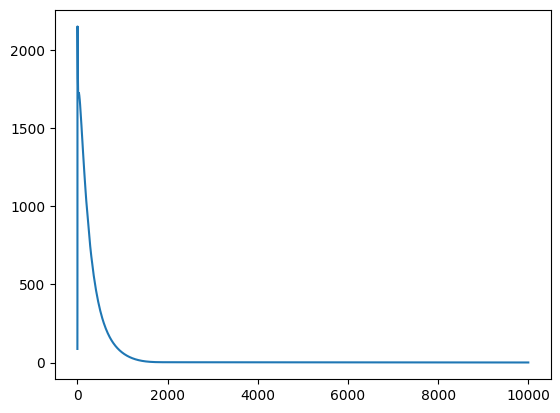

In [18]:
# Adagrad-Norm
f4 = ad_grad_norm(J, Df, w0, b0=0.5, eta=0.01, numb_iter=it_max)
plt.plot(f4[0])

# Exercício 6: Adam

Construa uma função `adam(Df, w0, alpha, beta1, beta2, epsilon, numb_iter)` que toma como entrada as funções `Df`, o ponto inicial `w0`, parametros positivos `alpha`, `beta1`, `beta2`, `epsilon` e o número de iterações `numb_iter` e implementa o método Adam iniciando de `w0`, $m_0=0$, $v_0=0$ e $k=0$: para cada $j$ézima coordenada:
\begin{align*}
m_{k+1}[j] &:= \beta_1\cdot m_{k}[j] + (1-\beta_1)\cdot\nabla f(w_k)[j],\\
v_{k+1}[j] &:= \beta_2\cdot v_{k}[j] + (1-\beta_2)\cdot(\nabla f(w_k)[j])^2,\\
\hat m_{k+1}[j] &:= \frac{1}{1-\beta_1^{k+1}}m_{k+1}[j],\\
\hat v_{k+1}[j] &:= \frac{1}{1-\beta_2^{k+1}}v_{k+1}[j],\\
w_{k+1}[j] &:= w_{k}[j] - \frac{\alpha}{\sqrt{\hat v_{k+1}[j]} + \epsilon }\hat m_{k+1}[j].
\end{align*}
Esta função deve retornar a sequência de valores da função `J(Df(w))` em cada um dos iterados `w`, isto é, a sequência das normas dos gradientes de $w_k$ ao longo da trajetória do método. A função também deve retornar o último iterado. 

Implemente a função com `alpha=0.001`, `beta1=0.9`, `beta2=0.999`, `epsilon=10**(-8)`. 

In [19]:
#Escreva código aqui

def adam(J, Df, w0, alpha=0.001, beta1=0.9, beta2=0.999, epsilon=10**(-8), numb_iter=100):
    w_k = w0.copy()
    m_k = np.zeros_like(w0)
    v_k = np.zeros_like(w0)
    norm_grad_w = []

    for k in range(numb_iter):
        grad = Df(w_k)
        norm_grad_w.append(J(grad))

        m_k = beta1 * m_k + (1 - beta1) * grad
        v_k = beta2 * v_k + (1 - beta2) * (grad**2)
        m_k_1 = m_k / (1 - beta1**(k+1))
        v_k_1 = v_k / (1 - beta2**(k+1))
        w_k = w_k - (alpha / (np.sqrt(v_k_1) + epsilon)) * m_k_1

    return norm_grad_w, w_k


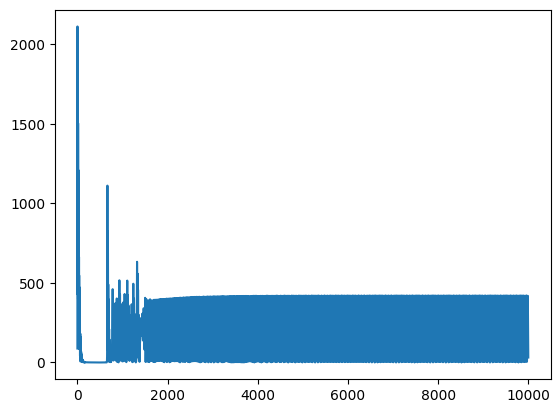

In [29]:
# Adam
f5 = adam(J, Df, w0, alpha=0.001, beta1=0.9, beta2=0.999, epsilon=10**(-8), numb_iter=it_max)
plt.plot(f5[0])

# Exercício 7: 

Implemente num mesmo gráfico os erros $\Vert\nabla f(w_k)\Vert$ de cada método em função no número de iterações.

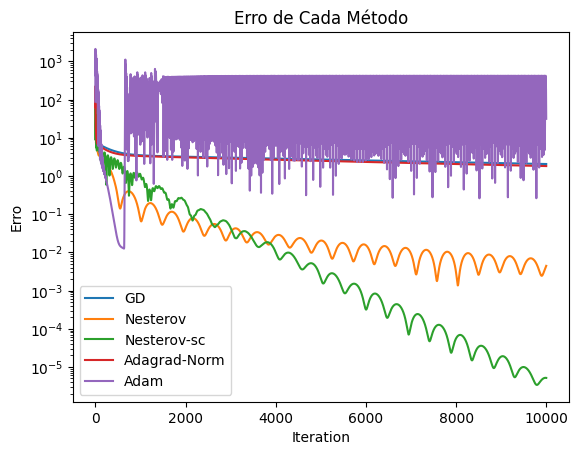

In [31]:
#Escreva código aqui

def erros_dos_metodos(gd, nest, nest_sc, adg, adam):
    # gradient descent
    #f1 = gd(J, Df, w0, la=1./L, numb_iter=it_max)
    plt.plot(gd[0], label='GD')

    # Nesterov accelerated gradient descent
    #f2 = accel_gd(J, Df, w0, la=1./L, numb_iter=it_max)
    plt.plot(nest[0], label='Nesterov')

    # Nesterov accelerated gradient descent for strongly convex functions
    #f3 = accel_gd_sc(J, Df, w0, la=1./L, kappa=L/l2, numb_iter=it_max)
    plt.plot(nest_sc[0], label='Nesterov-sc')

    # Adagrad-Norm
    #f4 = ad_grad_norm(J, Df, w0, b0=0.5, eta=0.01, numb_iter=it_max)
    plt.plot(adg[0], label='Adagrad-Norm')

    # Adam
    #f5 = adam(J, Df, w0, alpha=0.01, beta1=0.9, beta2=0.99, epsilon=10**(-8), numb_iter=it_max)
    plt.plot(adam[0], label='Adam')

    plt.legend()
    plt.xlabel('Iteration')
    plt.ylabel('Erro')
    plt.yscale('log')
    plt.title('Erro de Cada Método')
    plt.show()

erros_dos_metodos(f1, f2, f3, f4, f5)

# Exercício 8:

Experimente com os hyper-parâmetros de Adagrad-Norm and Adam para ver se eles podem chegar perto ou superar a performance de GD e Nesterov. Plote o gráfico como no Exercício 7. 

C:\Users\Matheus Pinto\AppData\Local\Temp\ipykernel_15112\1522629114.py:35: RuntimeWarning: overflow encountered in exp
  sigm_Xw = 1 / (1 + np.exp(-Xw))


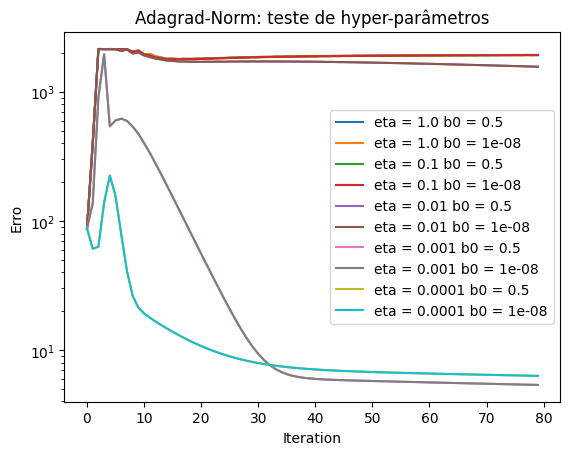

In [22]:
# Adagrad-Norm: testando os hyper-parâmetros 

etas = [1.0, 0.1, 0.01, 0.001, 0.0001]
b0s = [0.5, 10**(-8)]

for eta in etas:
    for b0 in b0s:
        adg = ad_grad_norm(J, Df, w0, b0=b0, eta=eta, numb_iter=80)
        plt.plot(adg[0], label=f'eta = {eta} b0 = {b0}')

plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Erro')
plt.title('Adagrad-Norm: teste de hyper-parâmetros')
plt.yscale('log')
plt.show()

C:\Users\Matheus Pinto\AppData\Local\Temp\ipykernel_15112\1522629114.py:35: RuntimeWarning: overflow encountered in exp
  sigm_Xw = 1 / (1 + np.exp(-Xw))


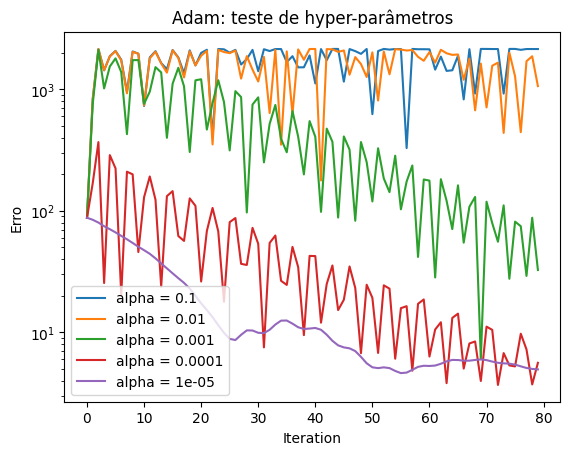

In [27]:
# Adam: testando os hyper-parâmetros 

alphas = [0.1, 0.01, 0.001, 0.0001, 0.00001]
# manteremos beta1=0.9 e beta2=0.999

for alpha in alphas:

    ad = adam(J, Df, w0, alpha=alpha, beta1=0.9, beta2=0.999, epsilon=10**(-8), numb_iter=80)
    plt.plot(ad[0], label=f'alpha = {alpha}')

plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Erro')
plt.yscale('log')
plt.title('Adam: teste de hyper-parâmetros')
plt.show()

In [33]:
f4 = ad_grad_norm(J, Df, w0, b0=0.5, eta=0.0001, numb_iter=it_max)
f5 = adam(J, Df, w0, alpha=0.0001, beta1=0.9, beta2=0.999, epsilon=10**(-8), numb_iter=it_max)


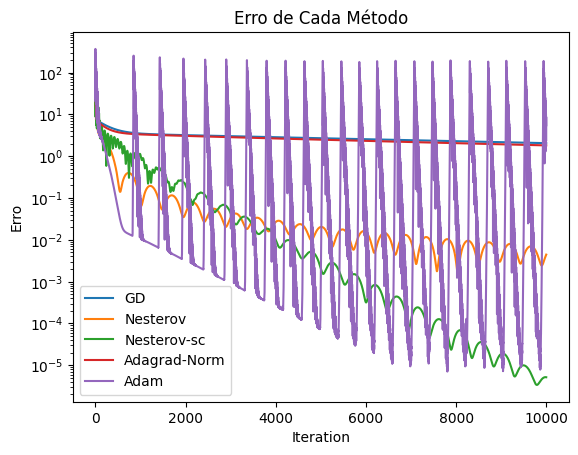

In [34]:

erros_dos_metodos(f1, f2, f3, f4, f5)